#**MACHINE LEARNING PERTEMUAN 2 DAN 3**


Nama  : Nala Kamila Azizy

NPM : F1F022024

# Latar Belakang

Algoritma prediktif, yang menjadi inti dari Pembelajaran Mesin (*Machine Learning*), menyediakan solusi penting untuk berbagai masalah klasifikasi dan regresi di seluruh domain, dari pemrosesan data bisnis hingga ilmu pengetahuan (Simanjuntak et al., 2024). Di antara berbagai metode, Decision Tree dan K-Nearest Neighbor (KNN) adalah dua pendekatan yang paling populer. Decision Tree adalah model yang sangat interpretif, bekerja dengan memecah data secara rekursif menjadi struktur pohon untuk memprediksi label kelas (Klasifikasi) berdasarkan metrik kemurnian (Gini Index), atau memprediksi nilai berkelanjutan (Regression Tree) dengan meminimalkan kesalahan kuadrat (Mean Squared Error) (Fanruan, 2025; Maharadja et al., 2021). Keunggulan Decision Tree terletak pada kemampuan representasi visualnya yang menyerupai proses pengambilan keputusan manusia, menjadikannya pilihan utama ketika interpretasi model sangat dibutuhkan.

Sementara itu, K-Nearest Neighbor (KNN) menawarkan pola yang berbeda. KNN adalah algoritma non-parametrik yang bekerja berdasarkan kedekatan data (instance-based), di mana prediksi dilakukan dengan mengidentifikasi k tetangga terdekat dalam ruang fitur (Illahi et al., 2023). KNN sangat sensitif terhadap skala fitur, sehingga membutuhkan tahapan preprocessing seperti standardisasi data. Perbedaan fundamental dalam cara kerja ini menciptakan trade-off utama dalam pemodelan: memilih interpretasi aturan yang jelas dari Decision Tree melawan kemampuan model berbasis jarak KNN yang fleksibel untuk menangkap batasan keputusan lokal. Oleh karena itu, perbandingan kinerja kedua algoritma, terutama setelah optimasi parameter, menjadi langkah penting untuk menentukan model mana yang paling efektif dan stabil dalam menggeneralisasi pola data.

# Rumusan Masalah

**PERTEMUAN 2**
1. Apa yang dimaksud dengan konsep dasar algoritma Decision Tree dalam machine learning?

2. Bagaimana cara membedakan antara Classification Tree dan Regression Tree berdasarkan fungsi serta tipe data yang diprediksi?

3. Bagaimana cara membangun dan menerapkan model Decision Tree untuk tugas klasifikasi menggunakan dataset yang tersedia?

4. Bagaimana cara mengevaluasi performa model Decision Tree menggunakan metrik evaluasi seperti confusion matrix dan accuracy score?

5. Bagaimana interpretasi hasil model yang dihasilkan, baik dalam bentuk metrik evaluasi maupun visualisasi pohon keputusan?

6. Bagaimana tingkat kemampuan mahasiswa dalam melakukan analisis dan penerapan Decision Tree pada dataset berbeda melalui latihan mandiri?

**PERTEMUAN 3**
1. Apa konsep dasar algoritma K-Nearest Neighbors (KNN) dalam menyelesaikan permasalahan klasifikasi?

2. Bagaimana langkah-langkah mengimplementasikan algoritma KNN menggunakan pustaka Scikit-learn di Python?

3. Bagaimana performa model KNN dapat dievaluasi menggunakan metrik evaluasi seperti accuracy score dan confusion matrix?


# Tujuan Penelitian


**PERTEMUAN II**
1.   Menjelaskan konsep dasar algoritma Decision Tree.
2.   Membedakan antara Classification Tree dan Regression Tree.
3.   Menerapkan Decision Tree untuk klasifikasi.
4.   Melakukan evaluasi model Decision Tree menggunakan confusion matrix dan accuracy score.
5.   Menginterpretasikan hasil model dalam bentuk visualisasi pohon keputusan.   
6.   Melatih kemampuan analisis melalui latihan mandiri menggunakan dataset lain.

**PERTEMUAN III**
1.   Memahami konsep dasar algoritma K-Nearest Neighbors (KNN) untuk klasifikasi.
2.   Mengimplementasikan KNN menggunakan pustaka Scikit-learn di Python.
3. Mengevaluasi performa model KNN menggunakan accuracy score dan confusion matrix


# Mengimpor _Libraries_

Berikut merupakan _library_ yang akan digunakan dalam _notebook_ ini:

In [15]:
!pip install feature_engine

In [16]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Memuat Data

Dataset yang akan digunakan adalah "Breast Cancer (Diagnostic)" untuk memprediksi apakah sebuah tumor bersifat ganas (malignant) atau jinak (benign).
Hingga akhirnya harus membandingkan kinerja kedua model yaitu (Decision Tree dan K-Nearest Neighbors (KNN)) tersebut dan memberikan kesimpulan model mana yang lebih baik untuk dataset ini. Dataset yang digunakan adalah Breast Cancer (Diagnostic) https://raw.githubusercontent.com/Royallist/DATA-MACHINE-LEARNING/refs/heads/main/data.csv.

In [17]:
# Data Loading

data_df = pd.read_csv('https://raw.githubusercontent.com/Royallist/DATA-MACHINE-LEARNING/refs/heads/main/data.csv')
data_df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


# Analisis Data Eksploratif

In [18]:
df = data_df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
print(df.describe())                 # untuk numerik
print(df.describe(include='object')) # untuk kategorik

       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

Berdasarkan hasil deskriptif statistik, jumlah data berjumlah 569 observasi dengan diagnosis terbagi menjadi dua kelas yaitu jinak (B) dan ganas (M), di mana mayoritas kasus merupakan tumor jinak sebanyak 357 data. Nilai rata-rata fitur ukuran sel seperti radius_mean, perimeter_mean, dan area_mean menunjukkan ukuran tumor cukup bervariasi dengan rentang yang lebar, sehingga mengindikasikan heterogenitas karakteristik sel pada pasien. Selain itu, fitur seperti concavity, compactness, dan concave points memiliki standar deviasi tinggi, menunjukkan variasi bentuk sel yang signifikan terutama pada tumor ganas.

diagnosis
B    357
M    212
Name: count, dtype: int64


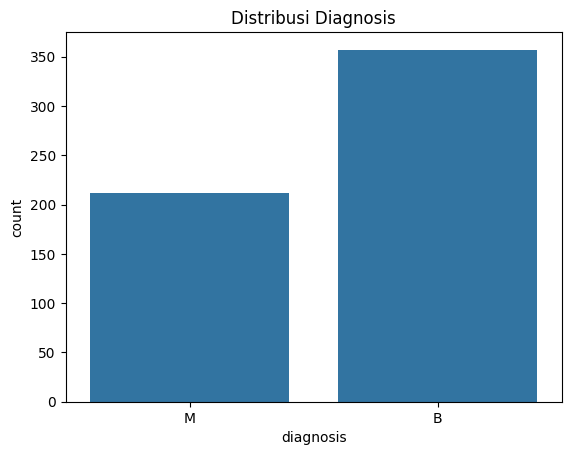

In [19]:
# ============================================================
# Cek distribusi variabel target (diagnosis)
# ============================================================
print(df['diagnosis'].value_counts())

sns.countplot(x='diagnosis', data=df)
plt.title("Distribusi Diagnosis")
plt.show()

Berdasarkan hasil histogram variabel respon (diagnosis) menunjukkan bahwa dari 569 data kasus kanker payudara, terdapat 357 kasus tumor jinak dan 212 kasus tumor ganas. Hal ini menunjukkan bahwa sebagian besar pasien dalam dataset memiliki diagnosis tumor jinak dengan persentase sekitar 62,7%, sedangkan tumor ganas sebesar 37,3%.

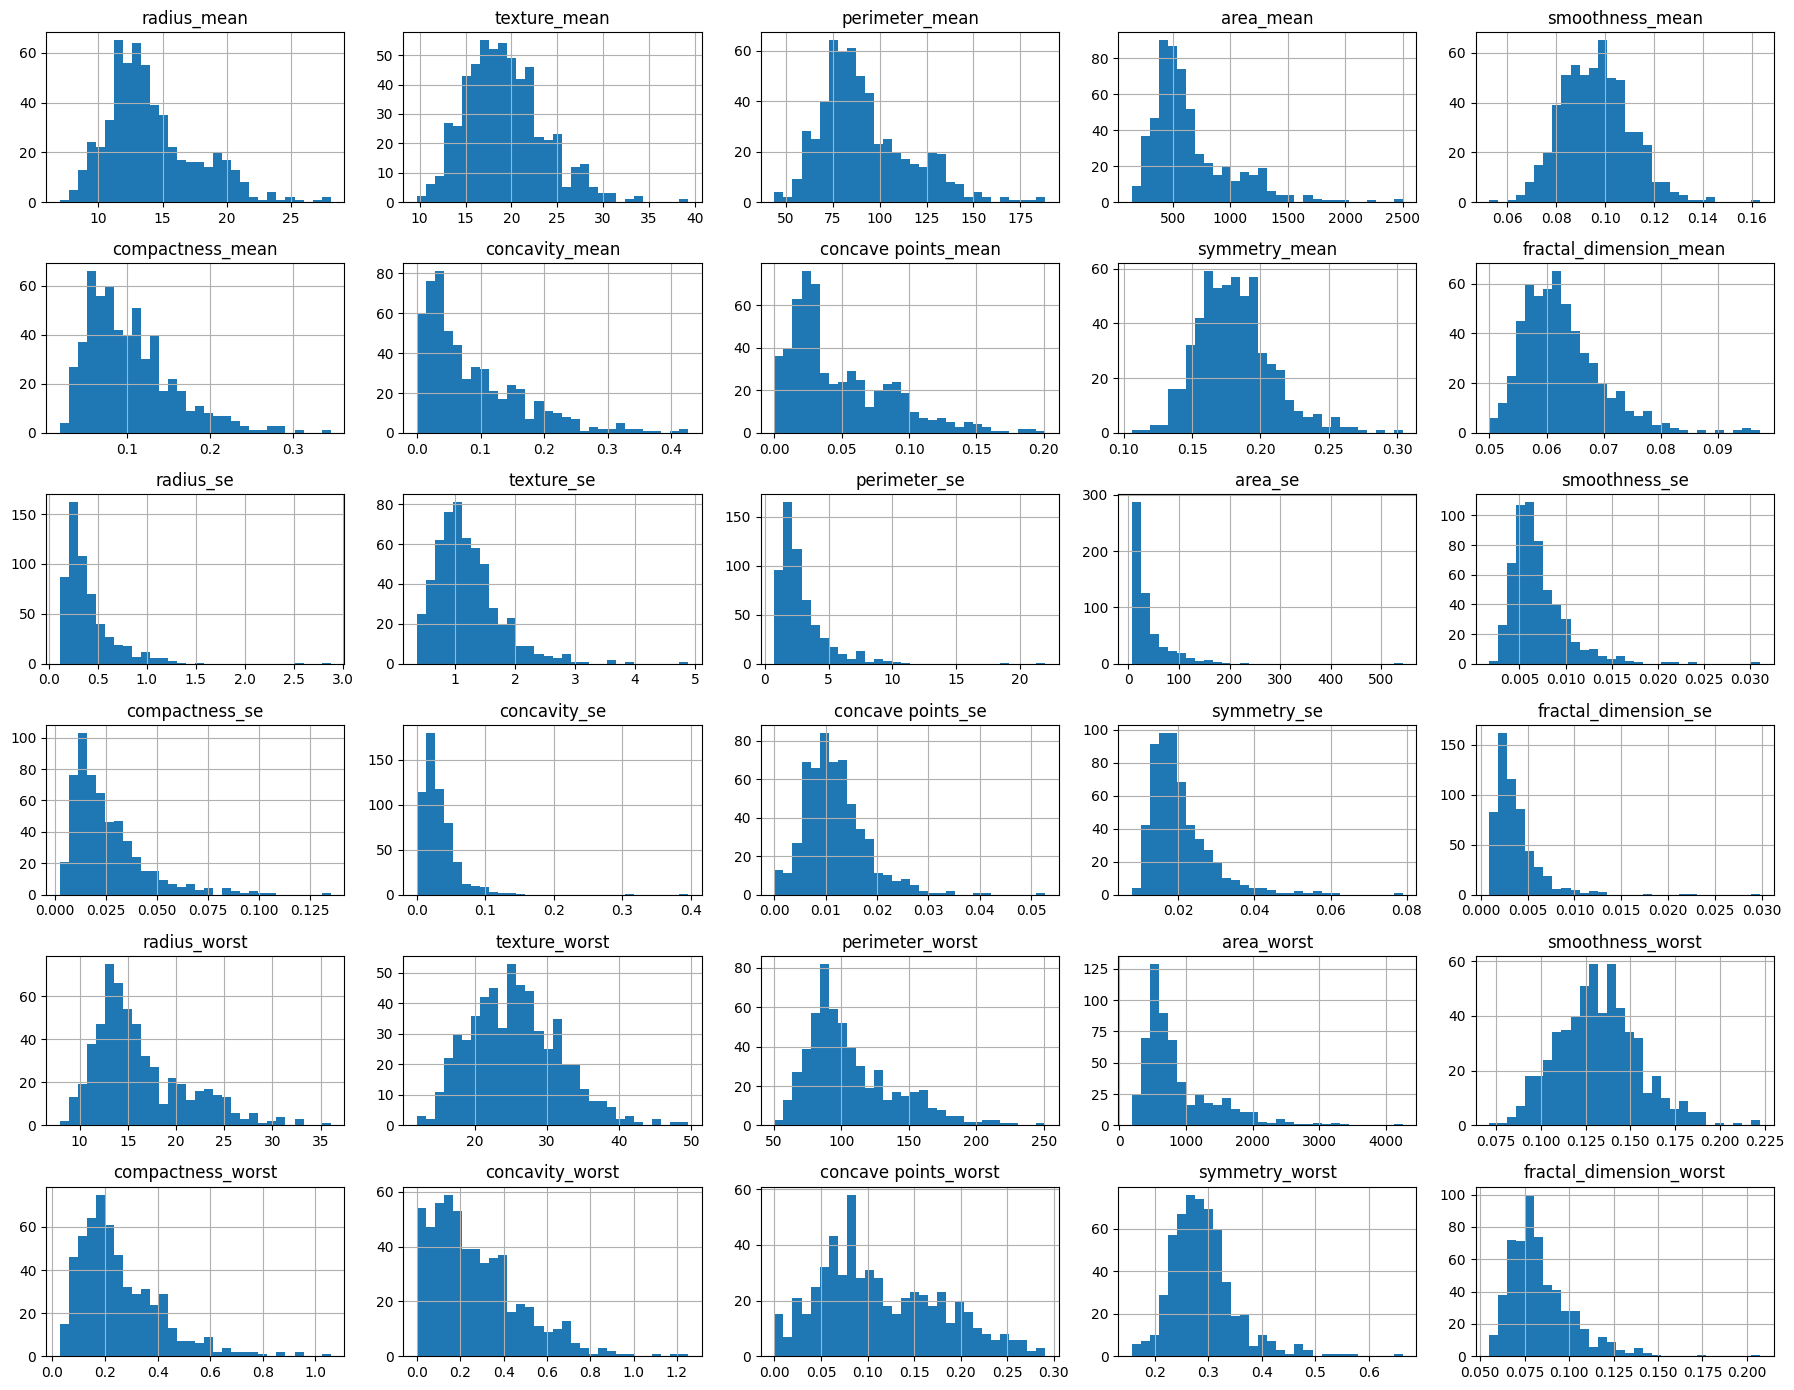

In [20]:
# ============================================================
# Distribusi variabel numerik (Histogram)
# ============================================================
df.hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

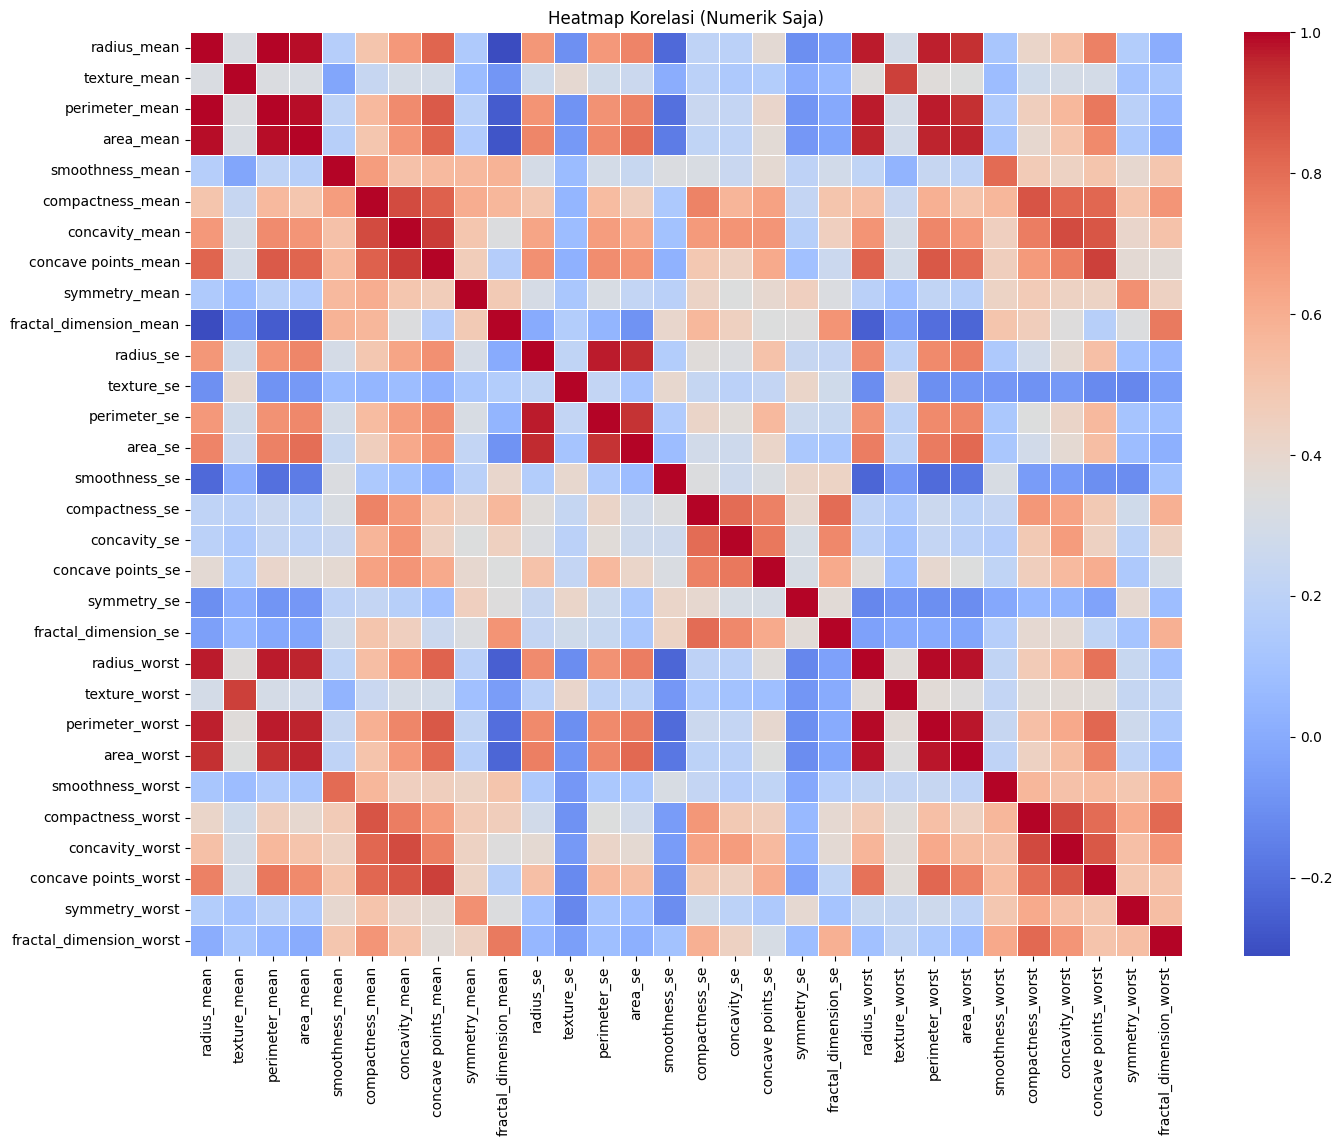

In [21]:
# ============================================================
# Correlation Heatmap
# ============================================================
# pilih hanya kolom numerik
df_num = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(16, 12))
sns.heatmap(df_num.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Heatmap Korelasi (Numerik Saja)")
plt.show()

Heatmap korelasi menunjukkan bahwa banyak fitur yang saling berkaitan kuat, terutama fitur ukuran sel seperti radius_mean, perimeter_mean, dan area_mean yang memiliki korelasi positif sangat tinggi, begitu juga pada kelompok fitur worst. Hal ini mengindikasikan adanya redundansi informasi atau multikolinearitas dalam dataset. Maka dari itu, diperlukan feature selection untuk menghindari adan

In [22]:
# =========================
# FEATURE SELECTION
# =========================
selected_features = [
    'radius_mean',
    'area_mean',
    'concavity_mean',
    'concave points_mean',
    'perimeter_worst'
    ]
df_baru = df[['diagnosis'] + selected_features].copy()
df_baru.head()

,diagnosis,radius_mean,area_mean,concavity_mean,concave points_mean,perimeter_worst
0,M,17.99,1001.0,0.3001,0.14710,184.60
1,M,20.57,1326.0,0.0869,0.07017,158.80
2,M,19.69,1203.0,0.1974,0.12790,152.50
3,M,11.42,386.1,0.2414,0.10520,98.87
4,M,20.29,1297.0,0.1980,0.10430,152.20


Pemilihan variabel dilakukan berdasarkan kombinasi relevansi klinis terhadap karakteristik keganasan tumor, pemilihan ini bertujuan untuk mengurangi multikolinearitas agar model tidak mempelajari informasi yang redundan. Dengan demikian, fitur terpilih yaitu radius_mean, area_mean, concavity_mean, concave points_mean, dan perimeter_worst dinilai paling representatif dan efektif digunakan pada pemodelan Decision Tree dan KNN. Meskipun radius_mean dan area_mean memiliki korelasi tinggi, keduanya tetap dipilih karena menunjukkan kontribusi prediktif yang kuat terhadap diagnosis kanker payudara serta merepresentasikan karakteristik morfologi tumor yang berbeda.

# _Feature Engineering_

## A - Missing Value

In [23]:
# ============================================================
#  Cek missing values
# ============================================================
print(df_baru.isnull().sum())

diagnosis              0
radius_mean            0
area_mean              0
concavity_mean         0
concave points_mean    0
perimeter_worst        0
dtype: int64


Berdasarkan hasil pemeriksaan missing values, dataset tidak memiliki data kosong pada variabel fitur yang terpilih maupun variabel target sehingga tidak diperlukan proses imputasi data.

## B - Kardinalitas

In [24]:
print("\nKardinalitas fitur kategorikal:")
for col in df_baru.select_dtypes(include=['object']).columns:
    print(f"{col} -> {df_baru[col].nunique()} kategori")


Kardinalitas fitur kategorikal:
diagnosis -> 2 kategori


Dataset ini hanya memiliki satu variabel kategorikal, yaitu diagnosis, yang terdiri dari dua kelas. Agar variabel ini dapat digunakan dalam proses pemodelan machine learning, khususnya algoritma klasifikasi seperti Decision Tree dan K-Nearest Neighbors (KNN), variabel tersebut perlu dikonversi ke bentuk numerik. Proses ini dilakukan melalui metode Label Encoding, sehingga kategori diagnosis dapat direpresentasikan dalam bentuk angka tanpa mengubah makna atau informasi yang dikandungnya.

## C- Splitting Data

In [25]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y
)
print("\nData Train:", X_train.shape)
print("Data Test:", X_test.shape)


Data Train: (455, 5)
Data Test: (114, 5)


Dataset dibagi menjadi dua bagian dengan proporsi 80% untuk data train dan 20% untuk data test, yang merupakan pembagian umum dalam pemodelan machine learning. Hasil pembagian menunjukkan bahwa data train berjumlah 455 baris dengan 5 fitur, sedangkan data test berjumlah 114 baris dengan 5 fitur. Data train digunakan untuk melatih model sehingga model dapat mempelajari pola dari dataset, sementara data test digunakan untuk mengevaluasi performa model terhadap data baru yang belum pernah dilihat sebelumnya. Pembagian ini dilakukan agar hasil evaluasi lebih objektif serta memastikan model memiliki kemampuan generalisasi yang baik dan tidak mengalami overfitting.

## D- Handling Outlier

In [26]:
# ===========================
# D. HANDLING OUTLIER (Optional – IQR)
# ===========================
# ====== D. HANDLING OUTLIER ======
Q1 = X_train.quantile(0.25)
Q3 = X_train.quantile(0.75)
IQR = Q3 - Q1

# Hapus baris outlier dari X_train
filtered_index = ~((X_train < (Q1 - 1.5 * IQR)) | (X_train > (Q3 + 1.5 * IQR))).any(axis=1)
X_train = X_train[filtered_index]

# Samakan y_train agar panjangnya sesuai X_train
y_train = y_train.loc[X_train.index]

# Reset index
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

print("\nJumlah data train setelah filtering outlier:", X_train.shape[0])


Jumlah data train setelah filtering outlier: 419


Pada tahap preprocessing, dilakukan penanganan outlier menggunakan metode Interquartile Range (IQR) untuk meningkatkan kualitas data sebelum proses pelatihan model. Outlier diidentifikasi berdasarkan nilai yang berada di luar rentang Q1 − 1.5×IQR hingga Q3 + 1.5×IQR, kemudian baris yang mengandung nilai ekstrem tersebut dihapus dari data latih. Setelah proses penyaringan, jumlah data train berkurang dari 466 menjadi 437 baris, sementara data test tetap tidak diubah agar tidak terjadi kebocoran data. Penyesuaian ulang indeks dan label target (y_train) juga dilakukan agar tetap konsisten dengan data fitur yang tersisa. Langkah ini bertujuan meningkatkan stabilitas model serta mengurangi kemungkinan model dipengaruhi oleh nilai-nilai ekstrem yang tidak mewakili karakteristik data secara keseluruhan.

## E- Scaling

In [27]:
# ===========================
# E. SCALING
# ===========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Proses scaling dilakukan untuk memastikan bahwa seluruh variabel berada pada rentang skala yang sebanding. Hal ini penting karena beberapa algoritma machine learning, seperti K-Nearest Neighbor (KNN), Support Vector Machine (SVM), Logistic Regression, dan Neural Network sangat sensitif terhadap perbedaan skala antar fitur. Tanpa scaling, fitur dengan nilai besar dapat mendominasi proses pembelajaran dan menyebabkan model bias. Dengan menerapkan StandardScaler, data ditransformasikan sehingga memiliki rata-rata 0 dan standar deviasi 1, sehingga model dapat belajar lebih optimal, lebih stabil, dan menghasilkan performa prediksi yang lebih akurat.

## F- Encoding

In [28]:
# ubah diagnosis menjadi angka
df_baru['diagnosis_num'] = df_baru['diagnosis'].map({'M':1, 'B':0})

X = df_baru.drop(columns=['diagnosis', 'diagnosis_num'])
y = df_baru['diagnosis_num']

Pada tahap ini, variabel diagnosis yang semula berbentuk kategori (B = jinak dan M = ganas) dikonversi menjadi variabel numerik menggunakan teknik label mapping, di mana kelas ganas diberi nilai 1 dan jinak diberi nilai 0. Proses ini dilakukan agar variabel target dapat digunakan dalam pemodelan supervised learning.

## G- Balancing Data

In [29]:
# ===========================
# G. BALANCING DATA (SMOTE)
# ===========================
smote = SMOTE(random_state=24)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nSetelah SMOTE:")
print(pd.Series(y_train).value_counts())


Setelah SMOTE:
diagnosis_num
0    282
1    282
Name: count, dtype: int64



Proses balancing data menggunakan Synthetic Minority Oversampling Technique (SMOTE) dilakukan karena dataset awal menunjukkan ketidakseimbangan kelas pada variabel target diagnosis. Ketidakseimbangan ini dapat menyebabkan model cenderung bias terhadap kelas yang dominan dan mengabaikan kelas minoritas, sehingga performa klasifikasi, khususnya dalam mengidentifikasi kelas minoritas menjadi rendah. Dengan menerapkan SMOTE, sampel sintetik dibuat berdasarkan kedekatan fitur antar observasi pada kelas minoritas, sehingga distribusi kelas menjadi lebih seimbang tanpa sekadar menduplikasi data. Langkah ini membantu meningkatkan kemampuan model dalam mengenali kedua kelas secara proporsional serta meningkatkan akurasi, recall, dan metrik evaluasi lainnya.


# _Training Model_

In [30]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

KNeighborsClassifier()

In [31]:
model_tree = DecisionTreeClassifier(random_state=24)
model_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=24)

## _Hyperparameter Tunning_

In [32]:
from sklearn.model_selection import GridSearchCV

param_knn = {"n_neighbors": range(3, 20)}
grid_knn = GridSearchCV(model_knn, param_knn, cv=5)
grid_knn.fit(X_train, y_train)

param_tree = {
    "criterion": ["gini", "entropy"],
    "max_depth": range(2, 20)
}
grid_tree = GridSearchCV(model_tree, param_tree, cv=5)
grid_tree.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
best_tree = grid_tree.best_estimator_

print("\nBest KNN:", grid_knn.best_params_)
print("Best Decision Tree:", grid_tree.best_params_)


Best KNN: {'n_neighbors': 3}
Best Decision Tree: {'criterion': 'gini', 'max_depth': 3}


Hasil tuning hyperparameter menunjukkan bahwa model K-Nearest Neighbors (KNN) mencapai performa terbaik ketika menggunakan 3 tetangga (n_neighbors = 3). Konfigurasi ini memberikan keseimbangan antara kompleksitas dan stabilitas prediksi, di mana nilai k yang terlalu kecil berpotensi menyebabkan model sensitif terhadap noise, sementara nilai k yang terlalu besar dapat menyebabkan model menjadi terlalu general. Sementara itu, untuk model Decision Tree, kombinasi parameter terbaik diperoleh pada penggunaan criterion = 'gini' dengan kedalaman maksimum (max_depth) = 3. Parameter ini memungkinkan pohon menghasilkan pemisahan yang informatif dengan tingkat kedalaman yang tidak berlebihan sehingga mencegah overfitting. Dengan demikian, kedua parameter yang diperoleh dari Grid Search dapat digunakan untuk pelatihan model final karena telah terbukti memberikan performa terbaik pada dataset.

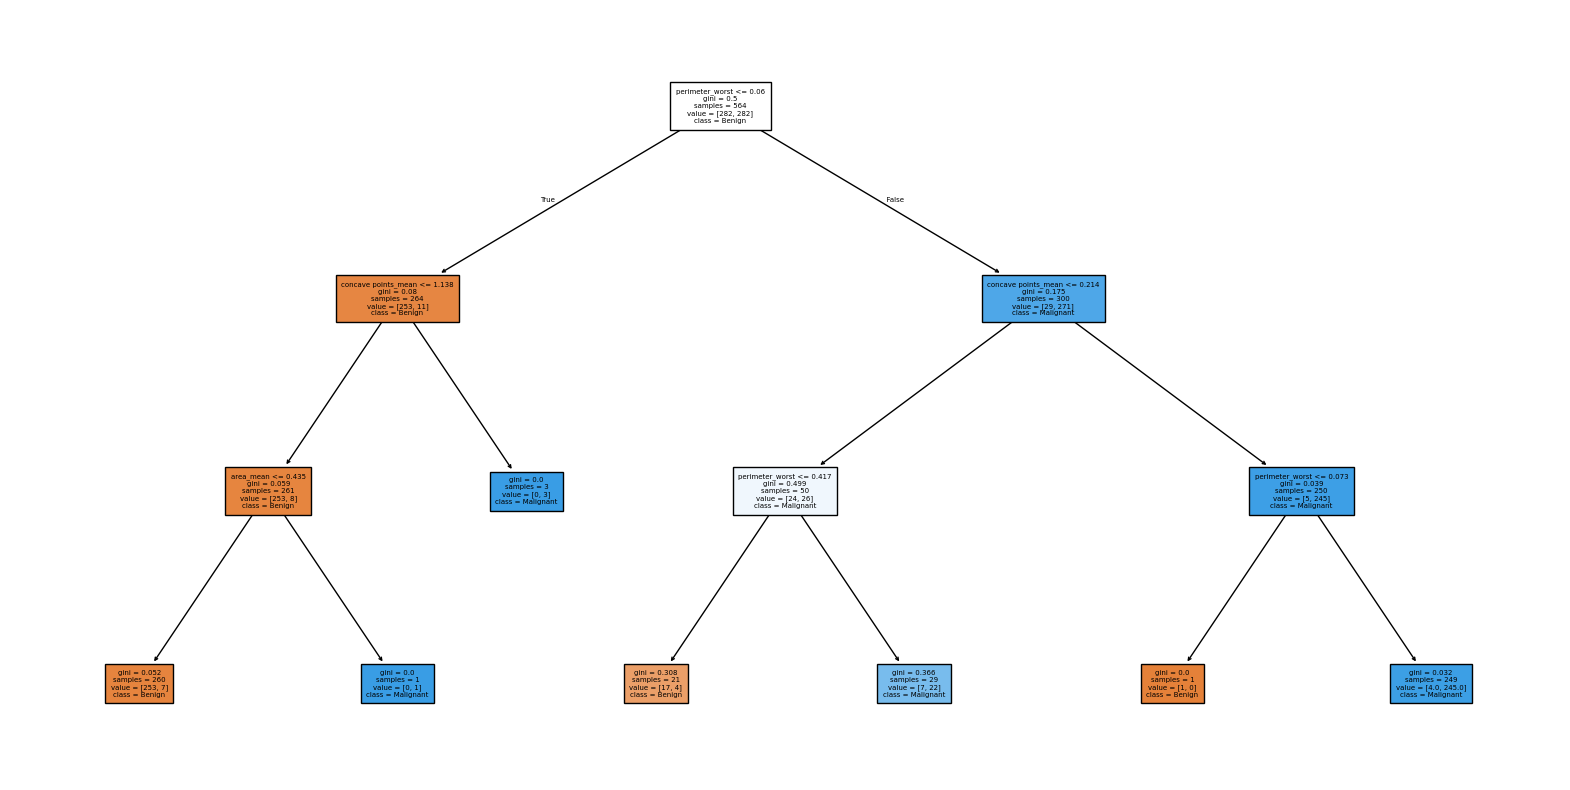

In [38]:
# Using Only Scikit-Learn
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

# Use the best parameters from GridSearchCV for Decision Tree
model_tree = DecisionTreeClassifier(max_depth=best_tree.max_depth, criterion=best_tree.criterion, random_state=24)
model_tree.fit(X_train, y_train)

plt.figure(figsize=(20,10))
tree.plot_tree(model_tree,
               feature_names=X.columns.tolist(),
               class_names=['B (Jinak)', 'M (Ganas)'],
               filled=True,
               fontsize= 5)
plt.show()

Dari hasil decision tree tersebut terlihat bahwa perimeter_worst menjadi faktor utama dalam membedakan tumor jinak atau ganas. Jika perimeter_worst bernilai kecil, model cenderung mengklasifikasikan tumor sebagai B (Jinak). Sebaliknya, jika perimeter_worst bernilai besar, peluang tumor tersebut M (ganas) juga meningkat. Setelah itu, model melihat concave points_mean, di mana nilai yang rendah menunjukkan bentuk sel yang lebih halus sehingga lebih mengarah ke jinak, sedangkan nilai yang lebih tinggi mengindikasikan bentuk yang tidak beraturan dan lebih mengarah ke Ganas. Pada bagian yang memprediksi jinak, model juga mempertimbangkan area_mean untuk memastikan ukuran sel masih aman. Secara keseluruhan, decision tree ini menegaskan bahwa tumor dengan perimeter_worst besar dan concave points_mean tinggi lebih berpotensi ganas, sedangkan ukuran yang lebih kecil dan bentuk yang lebih halus biasanya mengarah pada jinak.

# _Model Performance_


==================== KNN ====================

[PERFORMA PADA DATA LATIH (TRAIN)]
Accuracy (Train): 0.9663120567375887
Classification Report (Train):
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       282
           1       0.96      0.98      0.97       282

    accuracy                           0.97       564
   macro avg       0.97      0.97      0.97       564
weighted avg       0.97      0.97      0.97       564

Confusion Matrix (Train):
[[269  13]
 [  6 276]]


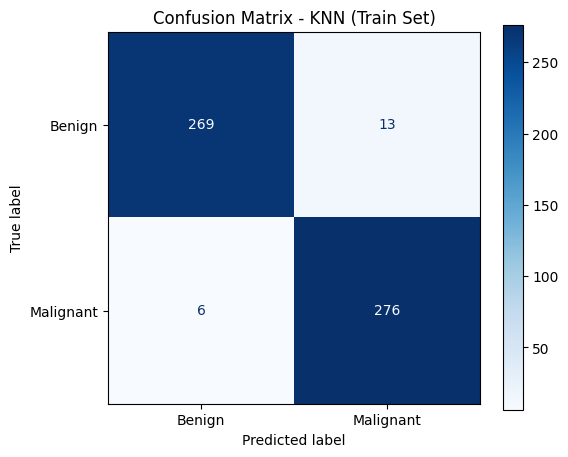


[PERFORMA PADA DATA UJI (TEST)]
Accuracy (Test): 0.9473684210526315
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.93      0.96        72
           1       0.89      0.98      0.93        42

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion Matrix (Test):
[[67  5]
 [ 1 41]]


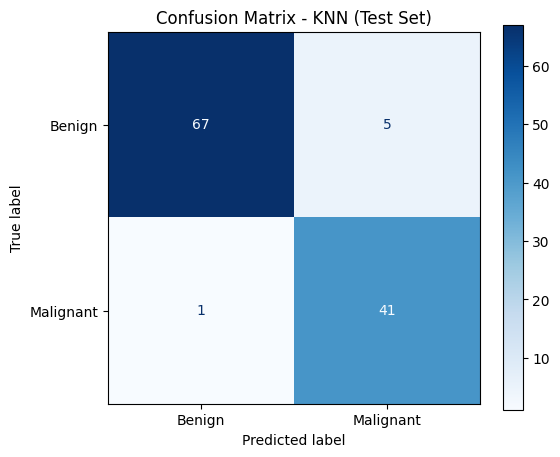


==================== Decision Tree ====================

[PERFORMA PADA DATA LATIH (TRAIN)]
Accuracy (Train): 0.9609929078014184
Classification Report (Train):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       282
           1       0.96      0.96      0.96       282

    accuracy                           0.96       564
   macro avg       0.96      0.96      0.96       564
weighted avg       0.96      0.96      0.96       564

Confusion Matrix (Train):
[[271  11]
 [ 11 271]]


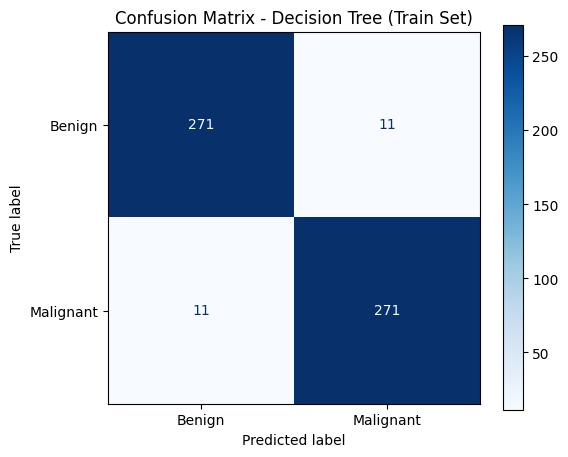


[PERFORMA PADA DATA UJI (TEST)]
Accuracy (Test): 0.9122807017543859
Classification Report (Test):
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        72
           1       0.85      0.93      0.89        42

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

Confusion Matrix (Test):
[[65  7]
 [ 3 39]]


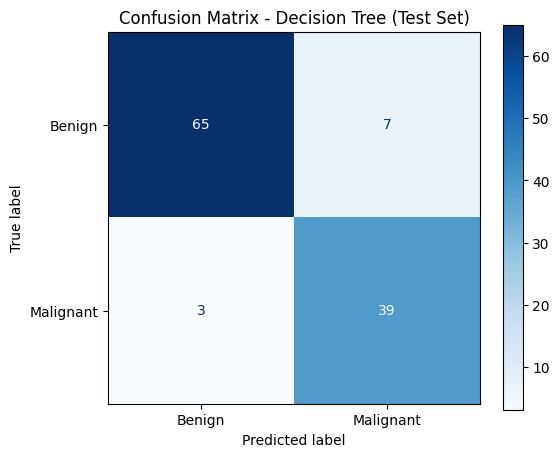

In [39]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "KNN": best_knn,
    "Decision Tree": best_tree
}

# Define common display labels
display_labels = ['B (Jinak)', 'M (Ganas)']

for name, model in models.items():
    print(f"\n==================== {name} ====================")

    # --- 1. EVALUASI PADA DATA LATIH (TRAIN SET) ---
    print("\n[PERFORMA PADA DATA LATIH (TRAIN)]")
    y_train_pred = model.predict(X_train)

    print("Accuracy (Train):", accuracy_score(y_train, y_train_pred))
    print("Classification Report (Train):")
    print(classification_report(y_train, y_train_pred))

    print("Confusion Matrix (Train):")
    cm_train = confusion_matrix(y_train, y_train_pred)
    print(cm_train)

    # Plot Confusion Matrix for Train Set
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=display_labels).plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'Confusion Matrix - {name} (Train Set)')
    plt.show()

    # --- 2. EVALUASI PADA DATA UJI (TEST SET) ---
    print("\n[PERFORMA PADA DATA UJI (TEST)]")
    y_test_pred = model.predict(X_test)

    print("Accuracy (Test):", accuracy_score(y_test, y_test_pred))
    print("Classification Report (Test):")
    print(classification_report(y_test, y_test_pred))

    print("Confusion Matrix (Test):")
    cm_test = confusion_matrix(y_test, y_test_pred)
    print(cm_test)

    # Plot Confusion Matrix for Test Set
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=display_labels).plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'Confusion Matrix - {name} (Test Set)')
    plt.show()


# Kesimpulan

Berdasarkan hasil evaluasi model menggunakan metrik accuracy, precision, recall, F1-score, dan confusion matrix, dapat disimpulkan bahwa algoritma K-Nearest Neighbors (KNN) menunjukkan performa yang lebih baik dibandingkan dengan model Decision Tree pada dataset yang digunakan.

Model KNN memperoleh nilai:

Accuracy : 0.9663 ~ 0.97

KNN sangat unggul dalam memprediksi Kelas 1 (Recall = 0.98) dan sangat jarang membuat kesalahan FP pada Kelas 0 (Precision = 0.99).

Sedangkan Decision Tree memperoleh nilai:

Accuracy : 0.9609 ~ 0.96

Kinerja Decision Tree pada Kelas 1 menurun drastis pada data uji (Precision Kelas 1 0.85 dan F1-Score menjadi 0.89). Ini menegaskan bahwa model terlalu terpaku pada noise dari data latih dan gagal menggeneralisasi batasan keputusan pada data baru.

Dalam konteks klasifikasi data kesehatan, Recall Kelas 1 menjadi metrik paling krusial karena meminimalkan False Negative (FN) (salah diagnosa positif). Berdasarkan hasil, model KNN menghasilkan Recall Kelas 1 yang lebih tinggi dibandingkan Decision Tree. Secara spesifik, KNN hanya menghasilkan 1 kasus FN pada data uji, sementara Decision Tree menghasilkan 3 kasus FN. Oleh karena itu, KNN adalah pilihan yang lebih tepat dan aman untuk deteksi kasus positif karena memiliki risiko kegagalan deteksi yang paling rendah.

Berdasarkan hasil evaluasi yang diperoleh, algoritma K-Nearest Neighbors (KNN) merupakan metode terbaik pada dataset ini, karena memiliki nilai akurasi lebih tinggi, kesalahan prediksi lebih rendah, dan performa lebih stabil dalam mengenali kelas target dibandingkan dengan Decision Tree.

Dengan demikian, KNN direkomendasikan sebagai model yang lebih optimal untuk digunakan pada proses klasifikasi dataset ini.

# Referensi

Illahi, P. K., Viana, A. R., Permata, M., & Pratama, M. Y. (2023). Penerapan Algoritma Decision Tree Dan Regresi Linear Untuk Klasifikasi Kanker Payudara. *SENTIMAS: Seminar Nasional Penelitian Dan Pengabdian Masyarakat*, *1*(1), 86-92.

Maharadja, N., Supriyadi, H., & Arini, E. (2021). Perbandingan Kinerja Regresi Decision Tree dan Regresi Linear Berganda untuk Prediksi BMI pada Dataset Asthma. *Jurnal Sains dan Statistika*, *2*  (2).

Simanjuntak, H., Siahaan, A. W., & Sitompul, H. (2024). Analisis Metode Decision Tree dan Regresi Logistik Sebagai Sistem Rekomendasi Kenaikan Golongan Berdasarkan Kinerja Pegawai pada Perusahaan. *JOURNAL STMIK PALANGKARAYA*, *11*(1), 44-53.

Fanruan. (2025, 6 Januari). *Apa itu Decision Trees? Arti, Struktur, dan Cara Kerjanya*. Fanruan.